# INF264 - Project 2

## Part 1 - Automatic Malware Detection
I will be training three different types of classifiers: a decision tree, a multilayer perceptron, and a support vector machine.

I start by importing the dataset and splitting into X and y.

In [1]:
import numpy as np

dataset = np.load("dataset.npz")
X, y = dataset["X"], dataset["y"]

Let us take a look at what the data we are working with actually looks like. I will plot one image from each of the 10 classes.

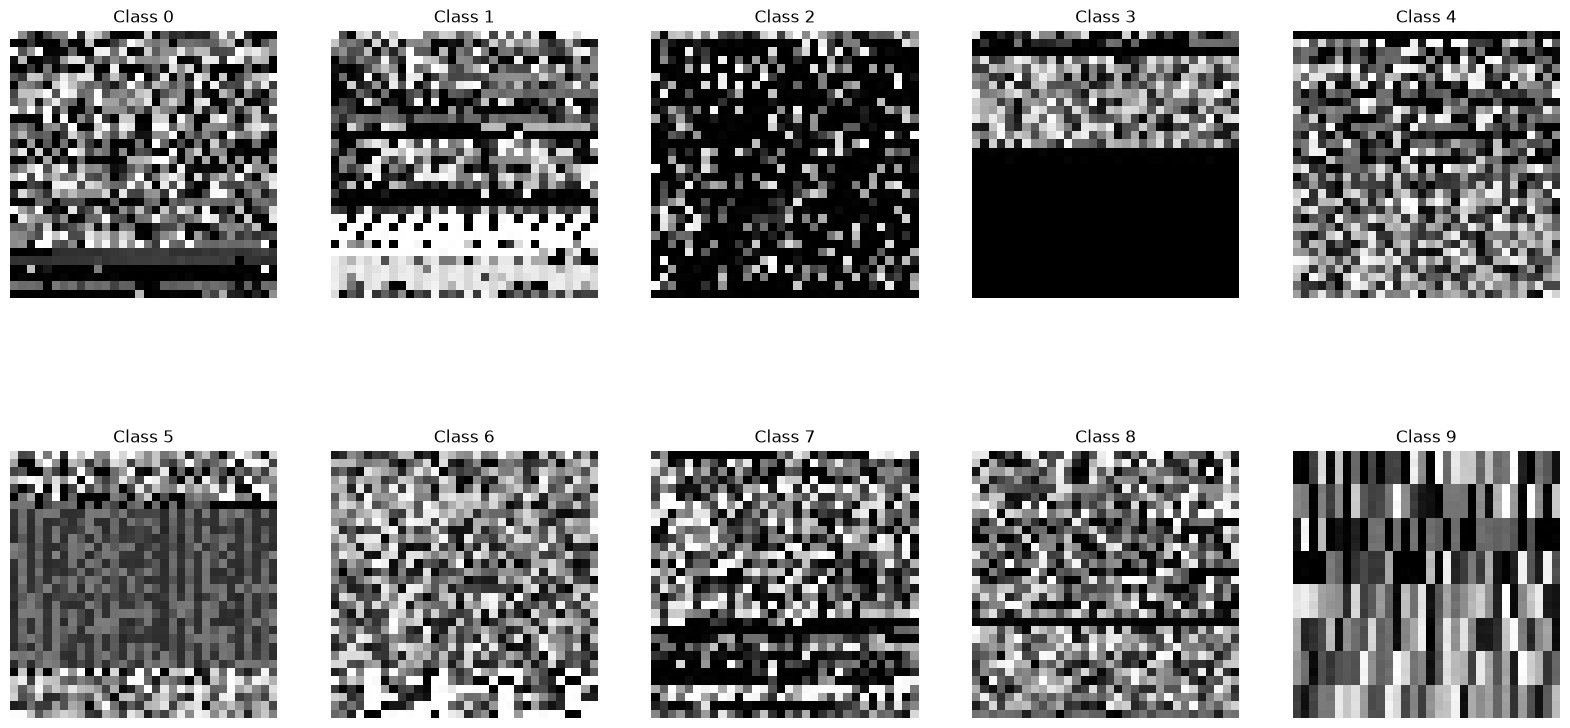

In [2]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
axs = axs.flatten()

for i in range(10):
    idx = np.where(y==i)[0][0]

    axs[i].imshow(X[idx].reshape(32,32), vmin=0, vmax=255, cmap="gray")
    axs[i].set_title(f"Class {i}")
    axs[i].axis("off")

plt.show()

I will look for duplicates in the dataset using np.unique. This allows me to return an array of all the indices of the first instance of a sample. I can use this to construct a new deduped version of the dataset.

In [3]:
_, indices = np.unique(X, return_index=True, axis=0)
print(f"We have {len(indices)} unique samples in our data.")

We have 10871 unique samples in our data.


I create a new version of X which does not contain duplicates.

In [4]:
X_deduped = X[indices]
y_deduped = y[indices]

I split the data into a training set and a testing set. I set the size of the test set to 0.15, which is ~1632 samples. I also set a seed, 67, so that all my results are reproducible.

In [5]:
from sklearn.model_selection import train_test_split

seed = 67
X_train, X_test, y_train, y_test = train_test_split(X_deduped, y_deduped, test_size=0.15, random_state=seed, stratify=y_deduped)
print(f"The training set has {len(y_train)} samples.")
print(f"The testing set has {len(y_test)} samples.")

The training set has 9240 samples.
The testing set has 1631 samples.


To measure the performance of my model I will use macro-F1-score. This gives me the mean F1-score for all classes. I will be doing grid search cross validation to find the best model in each model family. I have looked at the dataset and found that there are a lot of duplicates. I do not want there to be identical samples in the training set and the validation set, I therefore use GroupKFold for cross-validation, which guarantees that all identical samples are in the same set. There can still be identical samples in the test set, but since that does not influence the training of the model, it is fine.

In [6]:
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold

def macro_f1(y_true, y_pred):
    return f1_score(y_true=y_true, y_pred=y_pred, average="macro")

scorer = make_scorer(macro_f1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

### Classifier 1 - Decision tree

I do grid search to select a decision tree model. I decided to try different values for max_depth, min_samples_split and min_samples_leaf.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=seed)

param_grid_dt = {
    "max_depth": [2, 5, 10],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [5, 10],
    "criterion": ["entropy", "gini"]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=5, min_samples_split=10; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=5, min_samples_split=5; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=10, min_samples_split=5; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=5, min_samples_split=5; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=5, min_samples_split=5; total time=   1.1s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=10, min_samples_split=5; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=5, min_samples_split=10; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=5, min_samples_split=10; total time=   1.2s
[CV] END criterion=entropy, max_depth=2, min_samples_leaf=10, min_samples_split=5; total time=   1.5s
[CV] END criterion=entro

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': [2, 5, ...], 'min_samples_leaf': [5, 10], 'min_samples_split': [5, 10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multi

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5}
0.4882941141836978
              precision    recall  f1-score   support

           0       0.10      0.08      0.09       113
           1       0.93      0.77      0.84        48
           2       0.67      0.50      0.57       125
           3       0.75      0.83      0.79       103
           5       0.60      0.60      0.60       247
           6       0.69      0.75      0.72       551
           7       0.48      0.55      0.51       280
           8       0.59      0.47      0.52        88
           9       0.49      0.34      0.40        76

    accuracy                           0.60      1631
   macro avg       0.59      0.54      0.56      1631
weighted avg       0.59      0.60      0.59      1631

Macro-F1: 0.5604949497432904


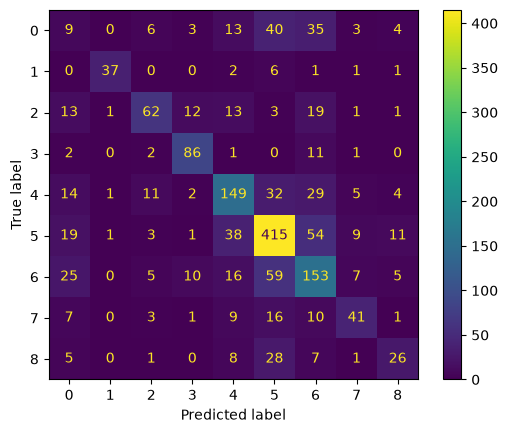

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(grid_search_dt.best_params_)
print(grid_search_dt.best_score_)

best_model_dt = grid_search_dt.best_estimator_

y_pred_dt = best_model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print(f"Macro-F1: {macro_f1(y_test, y_pred_dt)}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
cmd_dt = ConfusionMatrixDisplay(cm_dt)
cmd_dt.plot()
plt.show()

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

pipe_mlp = Pipeline([
    ("scaler", MinMaxScaler()),
    ("mlp", MLPClassifier(random_state=seed))
])

param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(128,), (64,), (32, 16,)],
    "mlp__activation": ["relu"],
    "mlp__alpha": [0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

grid_search_mlp = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid_mlp,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=2
)

grid_search_mlp.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(128,), mlp__learning_rate_init=0.01; total time=   8.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(128,), mlp__learning_rate_init=0.01; total time=  15.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(128,), mlp__learning_rate_init=0.01; total time=  15.5s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(64,), mlp__learning_rate_init=0.001; total time=  15.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(64,), mlp__learning_rate_init=0.001; total time=  18.5s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(128,), mlp__learning_rate_init=0.001; total time=  20.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(128,), mlp__learning_rate_init=0.001; total time=  22.0s
[CV] END mlp__activation=re

/Users/magnus/School/inf264/project2/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(64,), mlp__learning_rate_init=0.01; total time=  18.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(32, 16), mlp__learning_rate_init=0.01; total time=   5.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(32, 16), mlp__learning_rate_init=0.01; total time=   4.5s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(32, 16), mlp__learning_rate_init=0.001; total time=  16.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(32, 16), mlp__learning_rate_init=0.001; total time=  19.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(32, 16), mlp__learning_rate_init=0.001; total time=  10.9s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=67))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['relu'], 'mlp__alpha': [0.001, 0.01], 'mlp__hidden_layer_sizes': [(128,), (64,), ...], 'mlp__learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` para

              precision    recall  f1-score   support

           0       0.26      0.20      0.23       113
           1       1.00      0.92      0.96        48
           2       0.80      0.72      0.76       125
           3       0.94      0.94      0.94       103
           5       0.78      0.75      0.76       247
           6       0.83      0.90      0.86       551
           7       0.79      0.79      0.79       280
           8       0.71      0.76      0.73        88
           9       0.78      0.70      0.74        76

    accuracy                           0.78      1631
   macro avg       0.76      0.74      0.75      1631
weighted avg       0.78      0.78      0.78      1631

Macro-F1: 0.7523861005494781


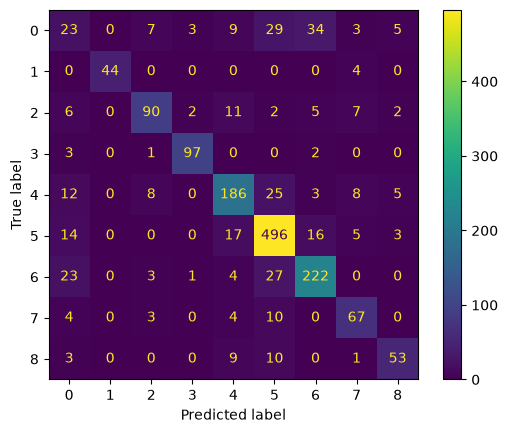

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_mlp = grid_search_mlp.best_estimator_

y_pred_mlp = best_model_mlp.predict(X_test)
print(classification_report(y_test, y_pred_mlp))
print(f"Macro-F1: {macro_f1(y_test, y_pred_mlp)}")

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
cmd_mlp = ConfusionMatrixDisplay(cm_mlp)
cmd_mlp.plot()
plt.show()

In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced"))
])

param_grid_svc = {
    "svc__C": [0.01, 0.1],
    "svc__gamma": [0.001]
}

grid_search_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=2
)

grid_search_svc.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END .......................svc__C=0.1, svc__gamma=0.001; total time= 3.2min
[CV] END .......................svc__C=0.1, svc__gamma=0.001; total time= 3.2min
[CV] END .......................svc__C=0.1, svc__gamma=0.001; total time= 3.2min
[CV] END ......................svc__C=0.01, svc__gamma=0.001; total time= 3.9min
[CV] END ......................svc__C=0.01, svc__gamma=0.001; total time= 3.9min
[CV] END ......................svc__C=0.01, svc__gamma=0.001; total time= 3.9min


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': [0.01, 0.1], 'svc__gamma': [0.001]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plo

              precision    recall  f1-score   support

           0       0.17      0.33      0.22       113
           1       1.00      1.00      1.00        48
           2       0.91      0.97      0.94       125
           3       0.94      0.95      0.95       103
           5       0.99      0.57      0.72       247
           6       0.94      0.95      0.94       551
           7       0.84      0.75      0.79       280
           8       0.80      0.84      0.82        88
           9       0.76      0.88      0.82        76

    accuracy                           0.81      1631
   macro avg       0.82      0.80      0.80      1631
weighted avg       0.86      0.81      0.82      1631

Macro-F1: 0.8008467917766304


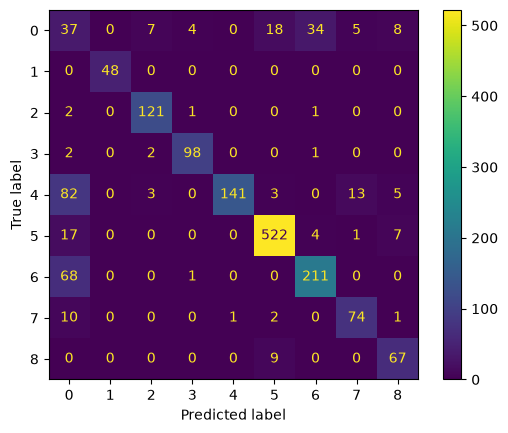

In [12]:
best_model_svc = grid_search_svc.best_estimator_

y_pred_svc = best_model_svc.predict(X_test)
print(classification_report(y_test, y_pred_svc))
print(f"Macro-F1: {macro_f1(y_test, y_pred_svc)}")

cm_svc = confusion_matrix(y_test, y_pred_svc)
cmd_svc = ConfusionMatrixDisplay(cm_svc)
cmd_svc.plot()
plt.show()

In [13]:
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier([("dt", dt), ("mlp", pipe_mlp), ("svc", pipe_svc)], voting="hard", n_jobs=-1, verbose=True)
vc.fit(X_train, y_train)


[Voting] ...................... (2 of 3) Processing mlp, total=  14.8s
[Voting] ....................... (1 of 3) Processing dt, total=  15.7s
[Voting] ...................... (3 of 3) Processing svc, total=  32.5s


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt', ...), ('mlp', ...), ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",True
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[DecisionTreeC...ndom_state=67), Pipeline(step...m_state=67))]), Pipeline(step...'balanced'))])]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,1024


              precision    recall  f1-score   support

           0       0.21      0.27      0.24       113
           1       0.92      0.98      0.95        48
           2       0.81      0.85      0.83       125
           3       0.92      0.92      0.92       103
           5       0.87      0.74      0.80       247
           6       0.89      0.93      0.91       551
           7       0.80      0.82      0.81       280
           8       0.89      0.77      0.83        88
           9       0.87      0.68      0.76        76

    accuracy                           0.81      1631
   macro avg       0.80      0.77      0.78      1631
weighted avg       0.82      0.81      0.81      1631

Macro-F1: 0.7829348908134254


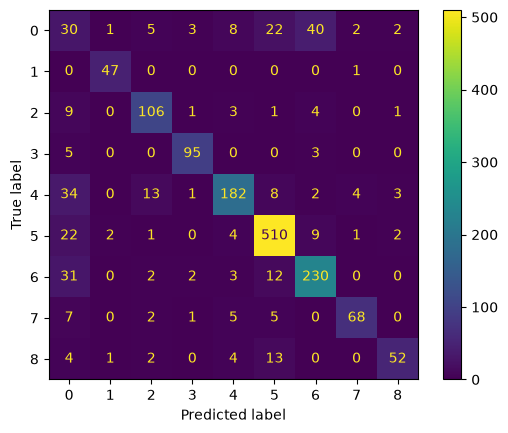

In [14]:
y_pred_vc = vc.predict(X_test)
print(classification_report(y_test, y_pred_vc))
print(f"Macro-F1: {macro_f1(y_test, y_pred_vc)}")

cm_vc = confusion_matrix(y_test, y_pred_vc)
cmd_vc = ConfusionMatrixDisplay(cm_vc)
cmd_vc.plot()
plt.show()